In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os, sys
sys.path.append(os.path.abspath('..'))
from src.data import save_data, get_raw

In [2]:
df = get_raw()
df.head()

Đã đọc thành công dữ liệu thô từ: C:\Users\YOGA\Desktop\01_Time Series\PROJECT\Github\Electricity-Load-Diagrams\data\raw\electricity_data.parquet


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
Timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Resample theo giờ và bỏ khách hàng MT_362
df = (
    df
    .resample("H")
    .sum()
    .sum(axis=1)
    .div(4)
)

# Chuyển thành DataFrame
df = df.to_frame(name="total_load")
df = df[df.index >= '2012-01-01']  # Giữ lại từ 2012 trở đi
df = df[df.index < "2015-01-01"]
df.head()

,total_load
Timestamp,
2012-01-01 00:00:00,104230.493821
2012-01-01 01:00:00,112550.368868
2012-01-01 02:00:00,110930.247627
2012-01-01 03:00:00,106191.754971
2012-01-01 04:00:00,103540.419166


In [4]:
# =====================================================
# 2. DST MARCH (23-HOUR DAY)
# Thay thế bằng NaN và dùng Nội suy tuyến tính (Linear Interpolation)
# Tránh tuyệt đối Data Leakage từ next_week
# =====================================================
march_dst = [
    "2012-03-25 01:00:00",
    "2013-03-31 01:00:00",
    "2014-03-30 01:00:00"
]

# Đổi giá trị 0kW tại các giờ này thành NaN
for t in march_dst:
    t = pd.Timestamp(t)
    if t in df.index:
        df.loc[t] = np.nan

# Lệnh nội suy này sẽ tự động lấy (0h00 + 2h00) / 2 của chính ngày hôm đó
df = df.interpolate(method='linear')

# =====================================================
# 3. DST OCTOBER (25-HOUR DAY)
# Giờ bị nhân đôi -> Chia 2
# =====================================================
october_dst = [
    "2012-10-28 01:00:00",
    "2013-10-27 01:00:00",
    "2014-10-26 01:00:00"
]

for t in october_dst:
    t = pd.Timestamp(t)
    if t in df.index:
        df.loc[t] = df.loc[t] / 2

# =====================================================
# 4. TOTAL LOAD
# =====================================================
df["total_load"] = df.sum(axis=1)

display(df.head())

,total_load
Timestamp,
2012-01-01 00:00:00,104230.493821
2012-01-01 01:00:00,112550.368868
2012-01-01 02:00:00,110930.247627
2012-01-01 03:00:00,106191.754971
2012-01-01 04:00:00,103540.419166


In [ ]:
from statsmodels.tsa.seasonal import MSTL
import pandas as pd
import matplotlib.pyplot as plt

# 1. Khởi tạo MSTL: Đưa tham số robust vào bên trong stl_kwargs
mstl = MSTL(
    df['total_load'], 
    periods=(24, 8760), 
    stl_kwargs={'robust': True}
)
result = mstl.fit()

# 2. Bóc tách dữ liệu
# result.seasonal của MSTL trả về một DataFrame chứa các cột chu kỳ tương ứng
df['trend'] = result.trend
df['seasonal_daily'] = result.seasonal['seasonal_24']
df['seasonal_yearly'] = result.seasonal['seasonal_8760']
df['resid'] = result.resid

# LƯU Ý: Nếu phiên bản statsmodels của bạn đặt tên cột khác, 
# bạn có thể dùng chỉ mục vị trí (iloc) để lấy ra cực kỳ an toàn:
# df['seasonal_daily'] = result.seasonal.iloc[:, 0]
# df['seasonal_yearly'] = result.seasonal.iloc[:, 1]

# 3. Trực quan hóa các thành phần sau khi bóc tách
plt.figure(figsize=(12, 8))
result.plot()
plt.tight_layout()
plt.show()

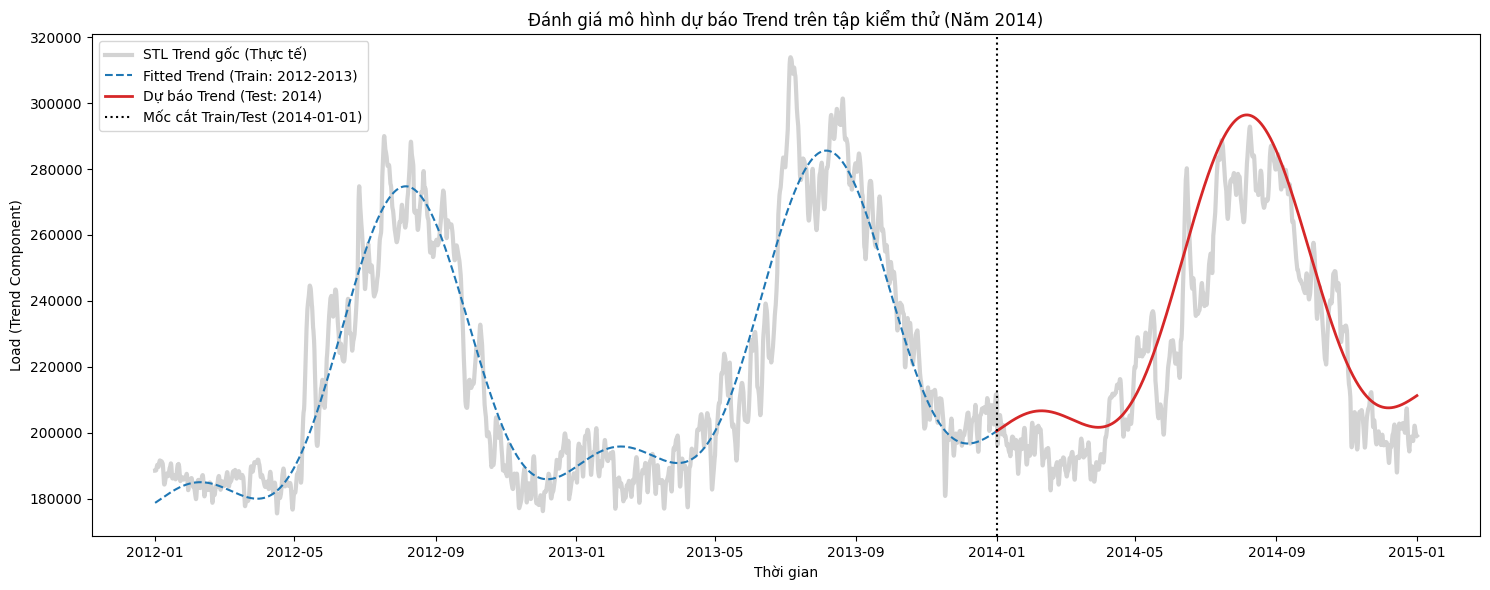

Sai số RMSE của dự báo Trend năm 2014: 14551.62


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Giả sử df_trend là dataframe chứa cột 'trend' và index là DatetimeIndex
# Loại bỏ các dòng NaN do hiệu ứng biên của STL
df_trend = df[['trend']].dropna().copy()

# 1. TẠO CÁC ĐẶC TRƯNG (TIME INDEX & FOURIER TERMS) CHO TOÀN BỘ DỮ LIỆU
df_trend['time_idx'] = np.arange(len(df_trend))

# Cấu hình Fourier chu kỳ năm (8760 giờ)
K = 2  # Số bậc Fourier
yearly_period = 365.25 * 24

for k in range(1, K + 1):
    df_trend[f'sin_{k}'] = np.sin(2 * np.pi * k * df_trend['time_idx'] / yearly_period)
    df_trend[f'cos_{k}'] = np.cos(2 * np.pi * k * df_trend['time_idx'] / yearly_period)

# 2. CHIA TẬP TRAIN VÀ TEST (Mốc cắt: 2014-01-01)
# Train: từ đầu đến trước ngày 2014-01-01
train_df = df_trend.loc[:'2013-12-31'].copy()
# Test: Toàn bộ năm 2014 đến hết dữ liệu
test_df = df_trend.loc['2014-01-01':].copy()

# Danh sách các cột feature dùng để train
features = ['time_idx'] + [f'sin_{k}' for k in range(1, K+1)] + [f'cos_{k}' for k in range(1, K+1)]

X_train = train_df[features]
y_train = train_df['trend']

X_test = test_df[features]
y_test = test_df['trend']

# 3. HUẤN LUYỆN MÔ HÌNH (Chỉ học trên tập Train)
model_trend = LinearRegression()
model_trend.fit(X_train, y_train)

# 4. DỰ BÁO TRÊN TẬP TEST (NĂM 2014)
test_df['trend_pred'] = model_trend.predict(X_test)
train_df['trend_fitted'] = model_trend.predict(X_train) # Fit trên train để xem độ bám

df['trend_pred'] = model_trend.predict(df_trend[features])  # Dự báo cho toàn bộ dữ liệu để trực quan hóa

# 5. TRỰC QUAN HÓA KẾT QUẢ QUÁ TRÌNH TEST
plt.figure(figsize=(15, 6))

# Vẽ đường Trend thực tế gốc
plt.plot(df_trend.index, df_trend['trend'], label='STL Trend gốc (Thực tế)', color='lightgray', linewidth=3)

# Vẽ đường mô hình học được trên tập Train
plt.plot(train_df.index, train_df['trend_fitted'], label='Fitted Trend (Train: 2012-2013)', color='tab:blue', linestyle='--')

# Vẽ đường DỰ BÁO cho tập Test (Năm 2014)
plt.plot(test_df.index, test_df['trend_pred'], label='Dự báo Trend (Test: 2014)', color='tab:red', linewidth=2)

# Vẽ đường kẻ dọc phân cách mốc Train/Test
plt.axvline(pd.to_datetime('2014-01-01'), color='black', linestyle=':', label='Mốc cắt Train/Test (2014-01-01)')

plt.title("Đánh giá mô hình dự báo Trend trên tập kiểm thử (Năm 2014)")
plt.xlabel("Thời gian")
plt.ylabel("Load (Trend Component)")
plt.legend()
plt.tight_layout()
plt.show()

# In ra sai số định lượng (RMSE) trên tập Test
rmse_test = np.sqrt(np.mean((test_df['trend'] - test_df['trend_pred'])**2))
print(f"Sai số RMSE của dự báo Trend năm 2014: {rmse_test:.2f}")

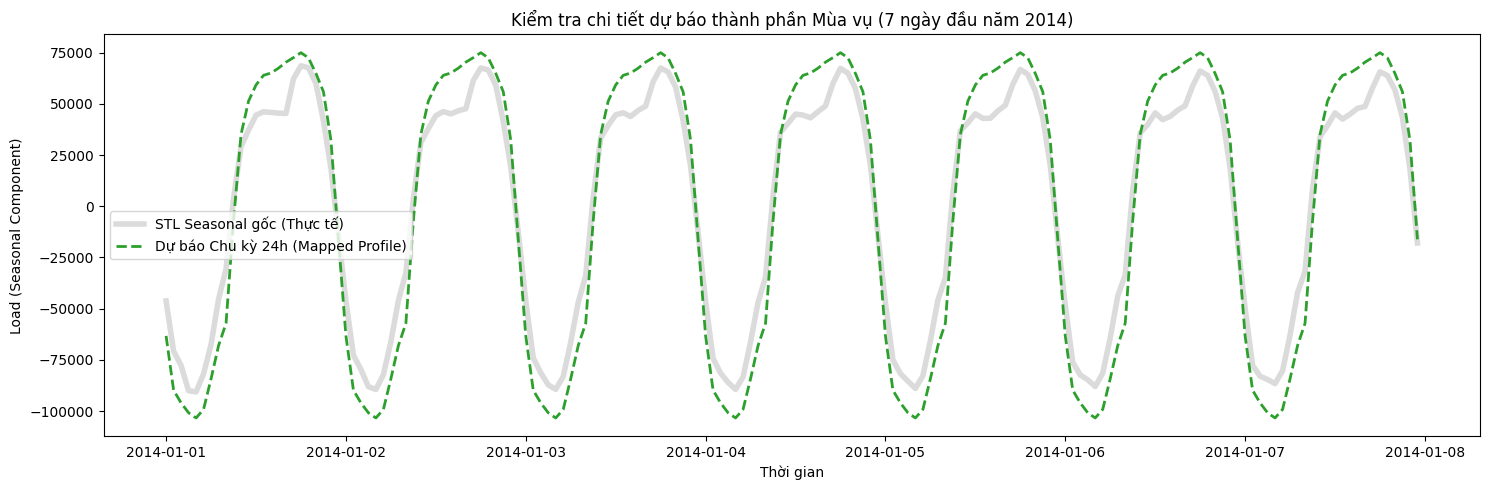

Mẫu hình dao động tải chuẩn theo 24 giờ học được từ Train:
Timestamp
0     -63266.05
1     -89754.82
2     -95964.94
3    -100792.58
4    -103317.74
5     -99146.98
6     -84207.82
7     -68036.29
8     -57123.44
9      -7165.70
10     35015.61
11     51277.59
12     59192.42
13     63892.82
14     65028.47
15     67392.84
16     70325.53
17     72532.41
18     74952.94
19     72412.49
20     64797.45
21     55866.39
22     32193.15
23    -16137.35
Name: seasonal, dtype: float64


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử df của bạn đã có cột 'seasonal' từ bước phân rã STL ban đầu
df_season = df[['seasonal']].dropna().copy()

# 1. CHIA TẬP TRAIN VÀ TEST (Cùng mốc 2014-01-01)
train_season = df_season.loc[:'2013-12-31'].copy()
test_season = df_season.loc['2014-01-01':].copy()

# 2. HỌC MẪU HÌNH MÙA VỤ TỪ TẬP TRAIN
# Tính giá trị seasonal trung bình cho từng khung giờ (0h - 23h) của giai đoạn 2012-2013
hourly_profile = train_season.groupby(train_season.index.hour)['seasonal'].mean()

# 3. DỰ BÁO CHO TẬP TEST (NĂM 2014)
# Ánh xạ (map) profile giờ chuẩn vào tập Test và Train
test_season['seasonal_pred'] = test_season.index.hour.map(hourly_profile)
train_season['seasonal_fitted'] = train_season.index.hour.map(hourly_profile)

df['seasonal_pred'] = df.index.hour.map(hourly_profile)

# 4. TRỰC QUAN HÓA KẾT QUẢ
# LƯU Ý: Vì chu kỳ 24h rất dày, nếu vẽ cả năm sẽ bị bết màu. 
# Chúng ta sẽ phóng to (zoom) vào 7 ngày đầu tiên của tập Test (năm 2014) để kiểm tra độ khớp.
zoom_start = '2014-01-01'
zoom_end = '2014-01-07'

plt.figure(figsize=(15, 5))

# Vẽ đường Seasonality gốc của STL bóc ra
plt.plot(test_season.loc[zoom_start:zoom_end].index, 
         test_season.loc[zoom_start:zoom_end, 'seasonal'], 
         label='STL Seasonal gốc (Thực tế)', color='lightgray', linewidth=4, alpha=0.8)

# Vẽ đường mô hình dự báo
plt.plot(test_season.loc[zoom_start:zoom_end].index, 
         test_season.loc[zoom_start:zoom_end, 'seasonal_pred'], 
         label='Dự báo Chu kỳ 24h (Mapped Profile)', color='tab:green', linewidth=2, linestyle='--')

plt.title("Kiểm tra chi tiết dự báo thành phần Mùa vụ (7 ngày đầu năm 2014)")
plt.xlabel("Thời gian")
plt.ylabel("Load (Seasonal Component)")
plt.legend()
plt.tight_layout()
plt.show()

# Kiểm tra profile 24 giờ học được
print("Mẫu hình dao động tải chuẩn theo 24 giờ học được từ Train:")
print(hourly_profile.round(2))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 307
[LightGBM] [Info] Number of data points in the train set: 17544, number of used features: 6
[LightGBM] [Info] Start training from score -509.760336
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

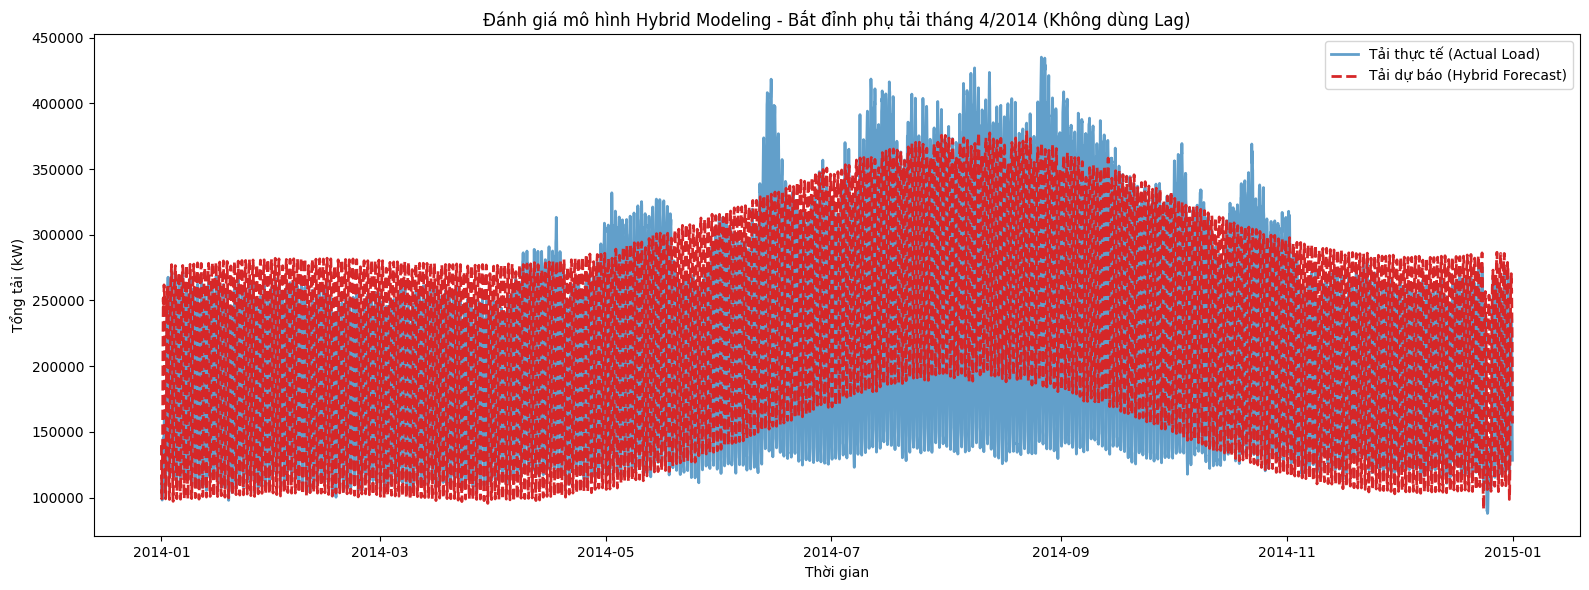

In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# Bỏ các dòng NaN từ STL decomposition
df_final = df.dropna().copy()

# ==========================================
# 1. TẠO CÁC ĐẶC TRƯNG THỜI GIAN (CALENDAR FEATURES)
# ==========================================
# Trích xuất triệt để thông tin từ DatetimeIndex thay vì dùng Lag
df_final['hour'] = df_final.index.hour
df_final['dayofweek'] = df_final.index.dayofweek
df_final['month'] = df_final.index.month
df_final['dayofyear'] = df_final.index.dayofyear
df_final['is_weekend'] = df_final['dayofweek'].isin([5, 6]).astype(int)

# Có thể thêm đặc trưng phân loại các buổi trong ngày để cây rẽ nhánh nhanh hơn
df_final['is_peak_hour'] = df_final['hour'].isin([10, 11, 13, 14, 15, 16]).astype(int)

# ==========================================
# 2. CHIA TẬP TRAIN / TEST (Mốc 2014-01-01)
# ==========================================
train_df = df_final.loc[:'2013-12-31'].copy()
test_df = df_final.loc['2014-01-01':].copy()

ml_features = ['hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend', 'is_peak_hour']

X_train_ml = train_df[ml_features]
y_train_ml = train_df['resid']

X_test_ml = test_df[ml_features]

# ==========================================
# 3. TRAIN LIGHTGBM TRÊN PHẦN DƯ
# ==========================================
# Báo cho LightGBM biết đâu là biến phân loại (Categorical) để tối ưu thuật toán rẽ nhánh
cat_features = ['hour', 'dayofweek', 'month', 'is_weekend', 'is_peak_hour']

model_resid = lgb.LGBMRegressor(
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model_resid.fit(
    X_train_ml, y_train_ml,
    categorical_feature=cat_features
)

# Dự báo thẳng phần dư cho toàn bộ năm 2014
test_df['resid_pred'] = model_resid.predict(X_test_ml)

# ==========================================
# 4. TỔNG HỢP KẾT QUẢ CUỐI CÙNG (RECONSTRUCTION)
# ==========================================
# Lắp ghép 3 mảnh dự báo: Trend + Seasonality + Residual
# (Đảm bảo test_df đã có sẵn 'trend_pred' và 'seasonal_pred' từ 2 bước chạy trước của bạn)

test_df['final_load_pred'] = test_df['trend_pred'] + test_season['seasonal_pred'] + test_df['resid_pred']

# Đánh giá sai số tổng thể RMSE trên thực tế gốc của năm 2014
final_rmse = np.sqrt(np.mean((test_df['total_load'] - test_df['final_load_pred'])**2))
print(f"★ Sai số RMSE TỔNG HỢP cho toàn bộ năm 2014: {final_rmse:.2f} kW")

# ==========================================
# 5. VẼ BIỂU ĐỒ KIỂM TRA ĐỘ KHỚP TOÀN HỆ THỐNG
# ==========================================
# Phóng to vào giai đoạn cao điểm (tháng 4/2014) để xem mô hình có bắt được đỉnh nhô lên không
view_start = '2014-01-01'
view_end = '2014-12-31'

plt.figure(figsize=(16, 6))
plt.plot(test_df.loc[view_start:view_end].index, 
         test_df.loc[view_start:view_end, 'total_load'], 
         label='Tải thực tế (Actual Load)', color='tab:blue', alpha=0.7, linewidth=2)

plt.plot(test_df.loc[view_start:view_end].index, 
         test_df.loc[view_start:view_end, 'final_load_pred'], 
         label='Tải dự báo (Hybrid Forecast)', color='tab:red', linestyle='--', linewidth=2)

plt.title("Đánh giá mô hình Hybrid Modeling - Bắt đỉnh phụ tải tháng 4/2014 (Không dùng Lag)")
plt.xlabel("Thời gian")
plt.ylabel("Tổng tải (kW)")
plt.legend()
plt.tight_layout()
plt.show()